[INFO] Loading data from C:\Users\fw4588\Documents\TWSA_Anomally_Over_GERD.csv...
[INFO] Identified data column in CSV as: 'GERD_TWSA'
[INFO] Data loaded. Shape: (287, 2). Target column: 'TWSA_anom (in)'

[INFO] Model will be trained on raw data column: 'TWSA_anom (in)'

[INFO] Lagged features created: X=(173, 6), y=(173, 1)

[INFO] Input features (X) and target values (y) have been properly scaled.

[INFO] Starting Neural Network Training...
Epoch 1/500


c:\Users\fw4588\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.8528 - mse: 17994.1191 - val_loss: 1.5998 - val_mse: 1.5998
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5853 - mse: 17983.0664 - val_loss: 1.3825 - val_mse: 1.3825
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4797 - mse: 17984.9824 - val_loss: 1.4396 - val_mse: 1.4396
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3873 - mse: 17972.0215 - val_loss: 1.5208 - val_mse: 1.5208
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3488 - mse: 17966.6816 - val_loss: 1.5762 - val_mse: 1.5762
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2448 - mse: 17967.7070 - val_loss: 1.5293 - val_mse: 1.5293
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2205 - mse: 17971.4551 - val_loss: 1.4929 - val_mse: 1.4929
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2149 - mse: 17958.8926 - val_loss: 1.5887 - val_mse: 1.5887
Epoch 9/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - 

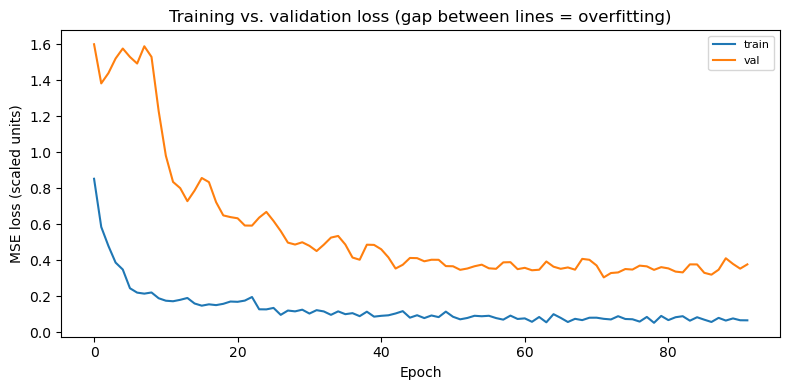

[INFO] Learning curve plot saved to twsa_learning_curves.png
[WARNING] Validation loss (0.3773) is notably higher than training loss (0.0667). This is a sign of overfitting.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

[EVALUATION] One-step-ahead Test MSE (scaled): 0.8064 | Test MAE (raw units): 4.0628 in

[INFO] Plotting model predictions vs. actuals on the test set...


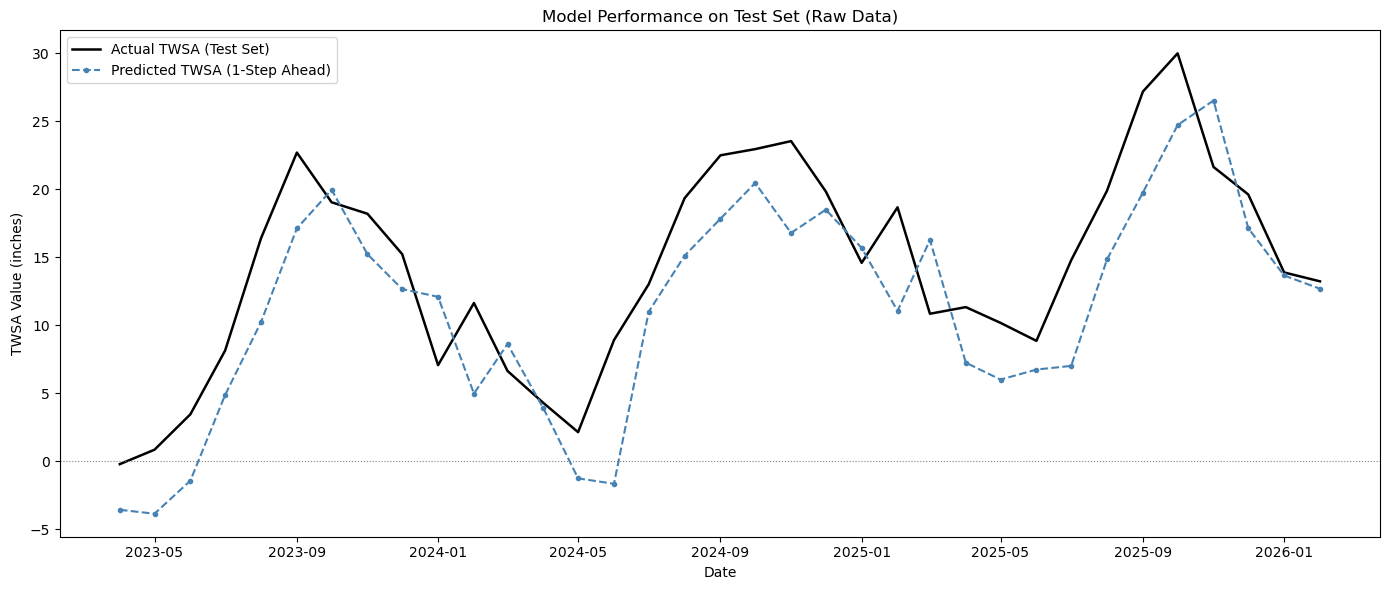

[INFO] Test set prediction plot saved to twsa_test_set_prediction_vs_actual.png
Filling gap: 2002-06-01 to 2002-07-01 (2 months)
  Skipping -- not enough real data before this gap (need 6 months).
Filling gap: 2003-06-01 to 2003-06-01 (1 months)
Filling gap: 2011-01-01 to 2011-01-01 (1 months)
Filling gap: 2011-06-01 to 2011-06-01 (1 months)
Filling gap: 2011-11-01 to 2011-11-01 (1 months)
Filling gap: 2012-05-01 to 2012-05-01 (1 months)
Filling gap: 2012-10-01 to 2012-10-01 (1 months)
Filling gap: 2013-03-01 to 2013-03-01 (1 months)
Filling gap: 2013-08-01 to 2013-09-01 (2 months)
Filling gap: 2014-02-01 to 2014-02-01 (1 months)
Filling gap: 2014-07-01 to 2014-07-01 (1 months)
Filling gap: 2014-12-01 to 2014-12-01 (1 months)
Filling gap: 2015-05-01 to 2015-06-01 (2 months)
Filling gap: 2015-10-01 to 2015-11-01 (2 months)
Filling gap: 2016-04-01 to 2016-04-01 (1 months)
Filling gap: 2016-09-01 to 2016-10-01 (2 months)
Filling gap: 2017-02-01 to 2017-02-01 (1 months)
Filling gap: 2017-0

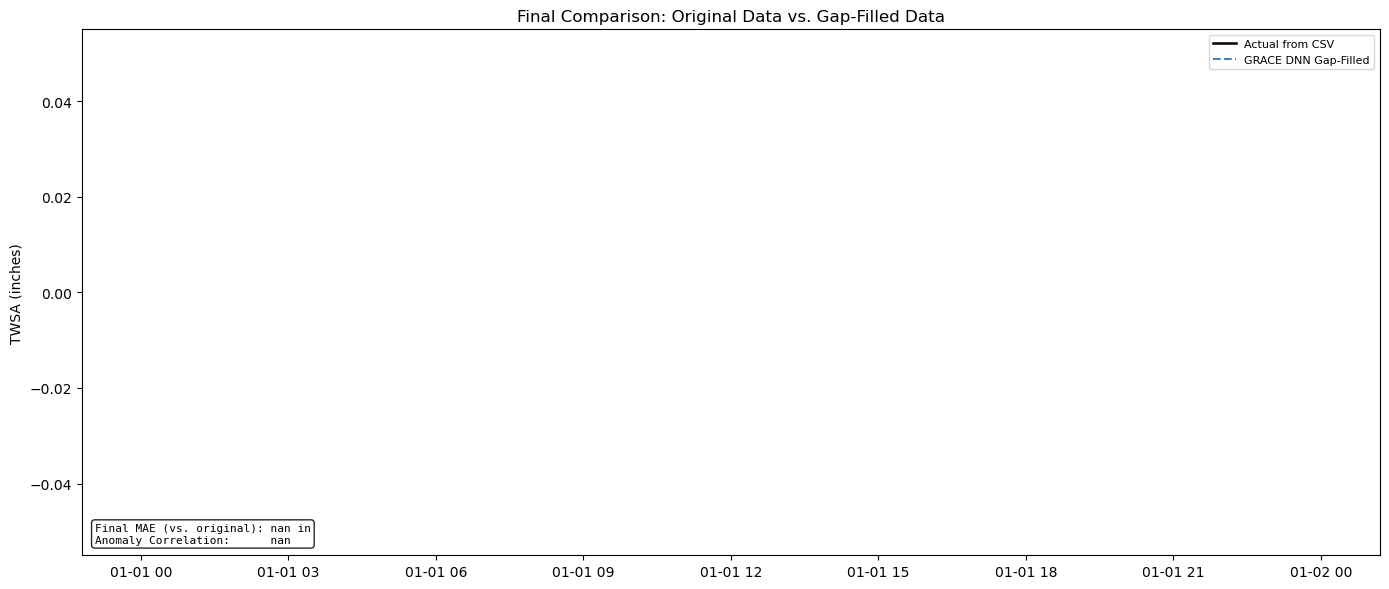

Comparison plot saved to twsa_comparison.png

SUMMARY OF VALIDATION DIAGNOSTICS (RAW DATA - SINGLE STEP PREDICTION)
- Overfitting check (Section 9): train loss 0.0667 vs val loss 0.3773 (scaled units)
- One-step test MAE (Section 10): 4.0628 in (raw TWSA units)
- Final Gap-Filled MAE (vs. original): nan in
- Final Anomaly Correlation:           nan


In [ ]:
"""
CODE 1
GRACE TWSA gap-filling with a neural net, raw data version.

This version simplifies the pipeline to train directly on the raw TWSA values,
bypassing the trend and seasonality removal. The model's task is to predict
the next raw TWSA value based on a history of previous raw values. This serves
as a baseline to evaluate model performance without the complexities of
data preprocessing and reconstruction.

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta

# =============================================================================
# 1. Load pre-processed TWSA data from CSV
# =============================================================================
CSV_PATH = r"C:\Users\fw4588\Documents\TWSA_Anomally_Over_GERD.csv"
from matplotlib.legend_handler import HandlerBase
target_col = "TWSA_anom (in)"

print(f"[INFO] Loading data from {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)

# Identify the data column programmatically (it's the one that isn't 'Date')
data_col_from_csv = [col for col in df.columns if col.lower() != 'date'][0]
print(f"[INFO] Identified data column in CSV as: '{data_col_from_csv}'")

# Prepare the DataFrame to match the structure expected by the rest of the script
df['Date'] = pd.to_datetime(df['Date'])
# The original notebook works in inches, and the CSV is in cm. Convert it.
df[target_col] = df[data_col_from_csv] * 0.3937
df = df[['Date', target_col]] # Keep only the necessary columns

# Ensure data is sorted and resampled to the start of the month, like the original pipeline
df = df.sort_values('Date').drop_duplicates(subset='Date')
df = df.set_index('Date')[[target_col]].resample('MS').mean().reset_index()

print(f"[INFO] Data loaded. Shape: {df.shape}. Target column: '{target_col}'")

# Define the column to be used for modeling. We are now using the raw target data directly.
modeling_col = target_col
print(f"\n[INFO] Model will be trained on raw data column: '{modeling_col}'")


# =============================================================================
# 4. Combined lag table for training
# =============================================================================
N_LAGS = 6
HORIZON = 1  # Predict only the single next value

X_list = []
y_list = []
dates_list = []  # Record the true date for each sample

# Loop across the full dataset contiguously
# Adjust loop to handle single-step horizon
for i in range(N_LAGS, len(df)):
    X_window = df[modeling_col].iloc[i - N_LAGS:i].values[::-1]  
    y_value = df[modeling_col].iloc[i]
    
    # We only skip if the INPUT history has NaNs (we need valid features to predict)
    if not np.isnan(X_window).any():
        X_list.append(X_window)
        # For targets, replace NaNs with a safe flag value (-999.0)
        y_list.append(y_value if not np.isnan(y_value) else -999.0)
        dates_list.append(df['Date'].iloc[i])

X = np.array(X_list)
# Reshape y to be a 2D array (n_samples, 1)
y = np.array(y_list).reshape(-1, 1)
sample_dates = np.array(dates_list)

print(f"\n[INFO] Lagged features created: X={X.shape}, y={y.shape}")

# =============================================================================
# 5. Train/test split + normalize
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into Train and Test sets chronologically
X_train_raw, X_test, y_train_raw, y_test, dates_train_raw, dates_test = train_test_split(
    X, y, sample_dates, test_size=0.2, shuffle=False
)

# Further split Train into Train and Validation sets manually
val_size = int(len(X_train_raw) * 0.2)
X_train = X_train_raw[:-val_size]
y_train = y_train_raw[:-val_size]
X_val = X_train_raw[-val_size:]
y_val = y_train_raw[-val_size:]
dates_train = dates_train_raw[:-val_size]
dates_val = dates_train_raw[-val_size:]

# --- PROPER SCALING ---
# 1. Scale the input features (X)
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

# 2. Scale the target variable (y)
y_scaler = StandardScaler()

# Fit scaler only on the valid (non-masked) training data
y_train_valid = y_train[y_train != -999.0]
# y_train is already (n_samples, 1), so we just need to filter it
y_scaler.fit(y_train_valid.reshape(-1, 1))

# Apply the scaler to all sets, preserving the mask
y_train_scaled = np.where(y_train == -999.0, -999.0, y_scaler.transform(y_train))
y_val_scaled = np.where(y_val == -999.0, -999.0, y_scaler.transform(y_val))
y_test_scaled = np.where(y_test == -999.0, -999.0, y_scaler.transform(y_test))

print("\n[INFO] Input features (X) and target values (y) have been properly scaled.")


# =============================================================================
# 6. Model: 6 lags -> 64 -> 32 -> 1
# =============================================================================
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

# Custom loss function that ignores our placeholder flag (-999.0)
def masked_mse(y_true, y_pred):
    # Create a mask where True represents real valid data points
    mask = tf.not_equal(y_true, -999.0)
    mask = tf.cast(mask, tf.float32)
    
    # Calculate standard squared error
    squared_errors = tf.square(y_true - y_pred)
    
    # Zero-out the errors belonging to the missing months
    masked_errors = squared_errors * mask
    
    # Return the mean over only the valid, unmasked elements
    return tf.reduce_sum(masked_errors) / (tf.reduce_sum(mask) + 1e-7)

# Build the model architecture for single-step prediction
def build_model(n_lags=N_LAGS):
    m = Sequential([
        Dense(32, activation='relu', input_shape=(n_lags,)),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)  # Output a single value
    ])
    # Compile using our custom masked loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    m.compile(optimizer=optimizer, loss=masked_mse, metrics=['mse'])
    return m

# =============================================================================
# 8. Train final model with early stopping
# =============================================================================
print("\n[INFO] Starting Neural Network Training...")
model = build_model()

from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=500,
    validation_data=(X_val_scaled, y_val_scaled),
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# =============================================================================
# 9. Learning curves
# =============================================================================
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss (scaled units)')
plt.title('Training vs. validation loss (gap between lines = overfitting)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('twsa_learning_curves.png', dpi=150)
plt.show()
print("[INFO] Learning curve plot saved to twsa_learning_curves.png")

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
if final_val_loss > 1.5 * final_train_loss:
    print(f"[WARNING] Validation loss ({final_val_loss:.4f}) is notably higher "
          f"than training loss ({final_train_loss:.4f}). This is a sign of "
          f"overfitting.")

# =============================================================================
# 10. One-step-ahead accuracy (raw units)
# =============================================================================
# Evaluate on scaled test data
test_loss_scaled, _ = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)

# For a meaningful MAE, we must compare in the original data scale
y_pred_test_scaled = model.predict(X_test_scaled)
y_pred_test_raw = y_scaler.inverse_transform(y_pred_test_scaled)

# Calculate MAE between raw (unscaled) values, ignoring masked steps
valid_mask = y_test != -999.0
mae_raw = np.mean(np.abs(y_test[valid_mask] - y_pred_test_raw[valid_mask]))

print(f"\n[EVALUATION] One-step-ahead Test MSE (scaled): {test_loss_scaled:.4f} | "
      f"Test MAE (raw units): {mae_raw:.4f} in")


# =============================================================================
# 10b. Plot Test Set Predictions vs. Actuals
# =============================================================================
print("\n[INFO] Plotting model predictions vs. actuals on the test set...")

# We already have the raw predictions from the previous step.
one_step_preds = y_pred_test_raw.flatten()
one_step_actuals = y_test.flatten()

# Filter out any masked values from the actuals for a clean plot
valid_indices = np.where(one_step_actuals != -999.0)[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test[valid_indices], one_step_actuals[valid_indices], color='black', linewidth=1.8, label='Actual TWSA (Test Set)')
ax.plot(dates_test[valid_indices], one_step_preds[valid_indices], color='steelblue', linestyle='--', marker='.', label='Predicted TWSA (1-Step Ahead)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Model Performance on Test Set (Raw Data)')
ax.set_xlabel('Date')
ax.set_ylabel('TWSA Value (inches)')
ax.legend()
plt.tight_layout()
plt.savefig('twsa_test_set_prediction_vs_actual.png', dpi=150)
plt.show()
print("[INFO] Test set prediction plot saved to twsa_test_set_prediction_vs_actual.png")


# =============================================================================
# 11. Gap-filling helpers
# =============================================================================
def find_missing_value_gaps(series):
    gaps, current_gap_start = [], None
    for date, missing in series.isna().items():
        if missing and current_gap_start is None:
            current_gap_start = date
        elif not missing and current_gap_start is not None:
            gap_dates = series.index[(series.index >= current_gap_start) & (series.index < date)]
            gaps.append({"start_date": current_gap_start, "end_date": gap_dates[-1], "num_missing_months": len(gap_dates)})
            current_gap_start = None
    if current_gap_start is not None:
        gap_dates = series.index[series.index >= current_gap_start]
        gaps.append({"start_date": current_gap_start, "end_date": gap_dates[-1], "num_missing_months": len(gap_dates)})
    return gaps


def fill_gap_recursive_mlp(model, x_scaler, y_scaler, history_values, num_missing_months, n_lags=N_LAGS):
    history = list(history_values)
    predictions = []
    for _ in range(num_missing_months):
        # The history is in the raw scale, so we use it directly
        feature_vec_raw = history[-n_lags:][::-1]
        
        # Scale the features for the model
        x_scaled = x_scaler.transform(np.array(feature_vec_raw, dtype=float).reshape(1, -1))
        
        # Predict in the scaled space
        y_pred_scaled = model.predict(x_scaled, verbose=0)[0, 0]
        
        # Inverse transform the prediction back to the raw scale
        y_pred_raw = y_scaler.inverse_transform(np.array([[y_pred_scaled]]))[0, 0]
        
        # Append the raw prediction to the history for the next step
        predictions.append(y_pred_raw)
        history.append(y_pred_raw)
        
    return predictions


def fill_all_gaps(model, x_scaler, y_scaler, series, n_lags=N_LAGS):
    filled_segments = {}
    for gap in find_missing_value_gaps(series):
        print(f"Filling gap: {gap['start_date'].date()} to {gap['end_date'].date()} ({gap['num_missing_months']} months)")
        before_gap = series[series.index < gap["start_date"]].dropna()
        if len(before_gap) < n_lags:
            print(f"  Skipping -- not enough real data before this gap (need {n_lags} months).")
            continue
        filled_values = fill_gap_recursive_mlp(model, x_scaler, y_scaler, before_gap.values[-n_lags:], gap["num_missing_months"], n_lags)
        gap_dates = pd.date_range(start=gap["start_date"], periods=gap["num_missing_months"], freq="MS")
        filled_segments[gap["start_date"]] = pd.Series(filled_values, index=gap_dates)
    return filled_segments

# =============================================================================
# 13. Gap filling
# =============================================================================
raw_series = df.set_index('Date')[modeling_col]

complete_series = raw_series.copy()
for filled_values in fill_all_gaps(model, x_scaler, y_scaler, raw_series).values():
    complete_series.update(filled_values)

complete_series.name = target_col
complete_series.to_csv("twsa_gapfilled_dnn.csv", header=[target_col])
print("\nDone. Complete gap-free monthly series saved to twsa_gapfilled_dnn.csv")

# =============================================================================
# 15. Compare against actual data from the source CSV
# =============================================================================
# Use the original, unprocessed data from the input CSV as the ground truth.
print("\n[INFO] Comparing gap-filled data against original (un-processed) data from the source CSV...")
actual_df = pd.read_csv(CSV_PATH)
actual_df['Date'] = pd.to_datetime(actual_df['Date'])
data_col = [col for col in actual_df.columns if col.lower() != 'date'][0]
actual_df[target_col] = actual_df[data_col] * 0.3937
actual = actual_df.set_index('Date')[[target_col]].rename(columns={target_col: 'Actual from CSV'})

grace = complete_series.copy()
grace.index = grace.index.to_period('M').to_timestamp()

comparison = pd.DataFrame({
    'Actual from CSV': actual['Actual from CSV'],
    'GRACE DNN Gap-Filled': grace
})

comp = comparison.dropna()

comp_anom = comp - comp.mean()

diff_raw  = comp['Actual from CSV'] - comp['GRACE DNN Gap-Filled']
diff_anom = comp_anom['Actual from CSV'] - comp_anom['GRACE DNN Gap-Filled']

mae_raw_final  = np.mean(np.abs(diff_raw))
corr_anom = comp_anom['Actual from CSV'].corr(comp_anom['GRACE DNN Gap-Filled'])

# --- Final Plotting ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(comp.index, comp['Actual from CSV'], label='Actual from CSV', color='black', linewidth=1.8)
ax.plot(comp.index, comp['GRACE DNN Gap-Filled'], label='GRACE DNN Gap-Filled', color='steelblue', linestyle='--')
ax.set_title('Final Comparison: Original Data vs. Gap-Filled Data')
ax.set_ylabel('TWSA (inches)')
ax.legend(loc='upper right', fontsize=8)

metrics_text = (
    f"Final MAE (vs. original): {mae_raw_final:.3f} in\n"
    f"Anomaly Correlation:      {corr_anom:.3f}"
)
ax.text(0.01, 0.02, metrics_text, transform=ax.transAxes,
         fontsize=8, verticalalignment='bottom', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('twsa_comparison.png', dpi=150)
plt.show()
print("Comparison plot saved to twsa_comparison.png")

# =============================================================================
# 17. Summary
# =============================================================================
print("\n" + "=" * 70)
print("SUMMARY OF VALIDATION DIAGNOSTICS (RAW DATA - SINGLE STEP PREDICTION)")
print("=" * 70)
print(f"- Overfitting check (Section 9): train loss {final_train_loss:.4f} vs "
      f"val loss {final_val_loss:.4f} (scaled units)")
print(f"- One-step test MAE (Section 10): {mae_raw:.4f} in (raw TWSA units)")
print(f"- Final Gap-Filled MAE (vs. original): {mae_raw_final:.3f} in")
print(f"- Final Anomaly Correlation:           {corr_anom:.3f}")


[INFO] Loading data from C:\Users\fw4588\Documents\TWSA_Anomally_Over_GERD.csv...
[INFO] Identified data column in CSV as: 'GERD_TWSA'
[INFO] Data loaded. Shape: (287, 2). Target column: 'TWSA_anom (in)'

[INFO] Model will be trained on raw data column: 'TWSA_anom (in)'

[INFO] Clipping data to only include dates before 2020-06-01...
[INFO] Data clipped. New shape: (218, 2)

[INFO] Lagged features created: X=(104, 6), y=(104, 1)

[INFO] Input features (X) and target values (y) have been properly scaled.

[INFO] Starting Neural Network Training...
Epoch 1/100


c:\Users\fw4588\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 1.0419 - mse: 14884.0586 - val_loss: 0.6459 - val_mse: 0.6459
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9782 - mse: 14891.4424 - val_loss: 0.5497 - val_mse: 0.5497
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6944 - mse: 14881.1230 - val_loss: 0.4642 - val_mse: 0.4642
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6300 - mse: 14882.6562 - val_loss: 0.3831 - val_mse: 0.3831
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5260 - mse: 14880.3291 - val_loss: 0.3055 - val_mse: 0.3055
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4680 - mse: 14899.9170 - val_loss: 0.2351 - val_mse: 0.2351
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3727 - mse: 14876.2500 - val_loss: 0.1850 - val_mse: 0.1850
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3420 - mse: 14876.1045 - val_loss: 0.1475 - val_mse: 0.1475
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - 

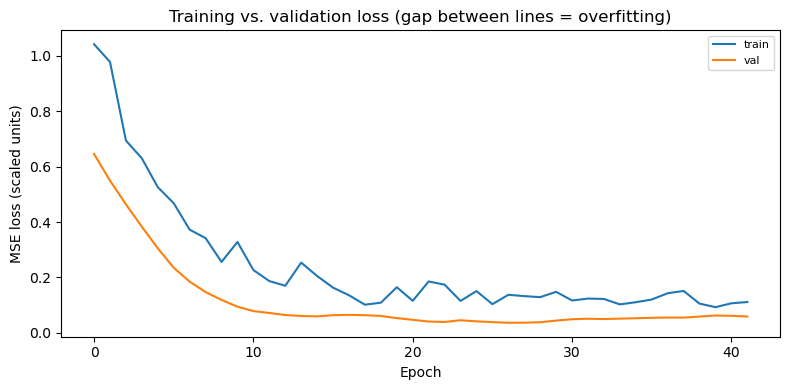

[INFO] Learning curve plot saved to twsa_learning_curves.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

[EVALUATION] One-step-ahead Test MSE (scaled): 0.2023 | Test MAE (raw units): 1.7459 in

[INFO] Plotting model predictions vs. actuals on the test set...


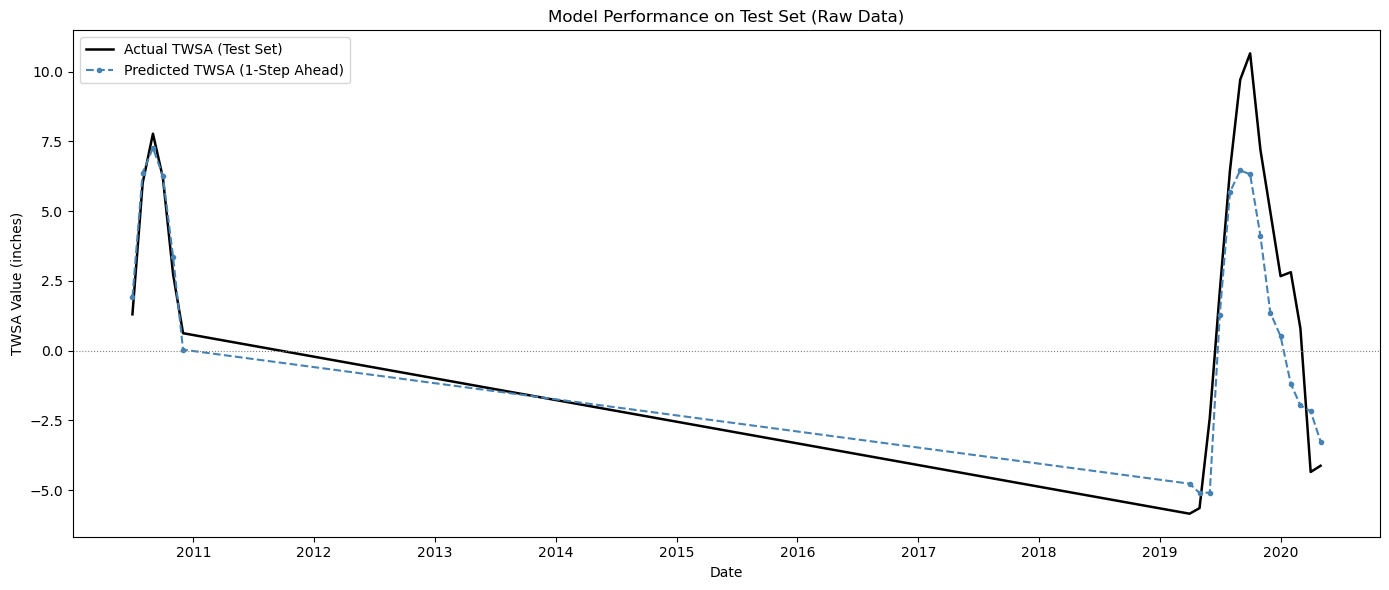

[INFO] Test set prediction plot saved to twsa_test_set_prediction_vs_actual.png
Filling gap: 2002-06-01 to 2002-07-01 (2 months)
  Skipping -- not enough real data before this gap (need 6 months).
Filling gap: 2003-06-01 to 2003-06-01 (1 months)
Filling gap: 2011-01-01 to 2011-01-01 (1 months)
Filling gap: 2011-06-01 to 2011-06-01 (1 months)
Filling gap: 2011-11-01 to 2011-11-01 (1 months)
Filling gap: 2012-05-01 to 2012-05-01 (1 months)
Filling gap: 2012-10-01 to 2012-10-01 (1 months)
Filling gap: 2013-03-01 to 2013-03-01 (1 months)
Filling gap: 2013-08-01 to 2013-09-01 (2 months)
Filling gap: 2014-02-01 to 2014-02-01 (1 months)
Filling gap: 2014-07-01 to 2014-07-01 (1 months)
Filling gap: 2014-12-01 to 2014-12-01 (1 months)
Filling gap: 2015-05-01 to 2015-06-01 (2 months)
Filling gap: 2015-10-01 to 2015-11-01 (2 months)
Filling gap: 2016-04-01 to 2016-04-01 (1 months)
Filling gap: 2016-09-01 to 2016-10-01 (2 months)
Filling gap: 2017-02-01 to 2017-02-01 (1 months)
Filling gap: 2017-0

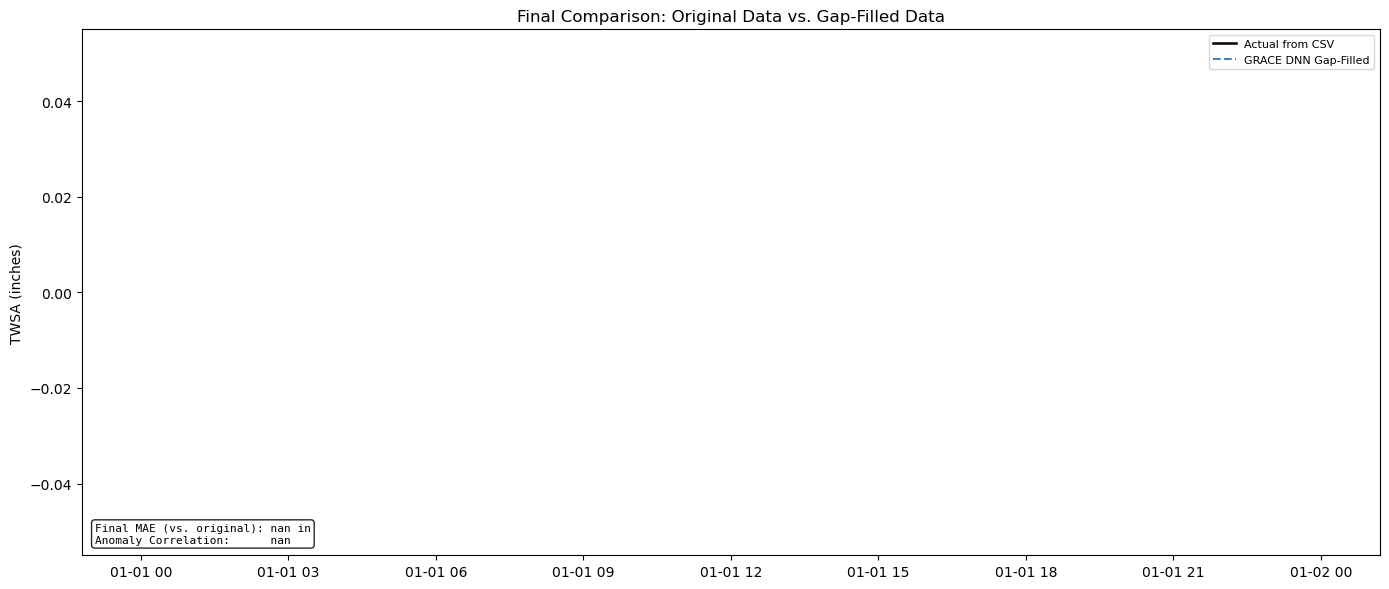

Comparison plot saved to twsa_comparison.png

SUMMARY OF VALIDATION DIAGNOSTICS (RAW DATA - SINGLE STEP PREDICTION)
- Overfitting check (Section 9): train loss 0.1115 vs val loss 0.0592 (scaled units)
- One-step test MAE (Section 10): 1.7459 in (raw TWSA units)
- Final Gap-Filled MAE (vs. original): nan in
- Final Anomaly Correlation:           nan


In [4]:
"""
GRACE TWSA gap-filling with a neural net, raw data version.

This version simplifies the pipeline to train directly on the raw TWSA values,
bypassing the trend and seasonality removal. The model's task is to predict
the next raw TWSA value based on a history of previous raw values. This serves
as a baseline to evaluate model performance without the complexities of
data preprocessing and reconstruction.

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta

# =============================================================================
# 1. Load pre-processed TWSA data from CSV
# =============================================================================
CSV_PATH = r"C:\Users\fw4588\Documents\TWSA_Anomally_Over_GERD.csv"
target_col = "TWSA_anom (in)"

print(f"[INFO] Loading data from {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)

# Identify the data column programmatically (it's the one that isn't 'Date')
data_col_from_csv = [col for col in df.columns if col.lower() != 'date'][0]
print(f"[INFO] Identified data column in CSV as: '{data_col_from_csv}'")

# Prepare the DataFrame to match the structure expected by the rest of the script
df['Date'] = pd.to_datetime(df['Date'])
# The original notebook works in inches, and the CSV is in cm. Convert it.
df[target_col] = df[data_col_from_csv] * 0.3937
df = df[['Date', target_col]] # Keep only the necessary columns

# Ensure data is sorted and resampled to the start of the month, like the original pipeline
df = df.sort_values('Date').drop_duplicates(subset='Date')
df = df.set_index('Date')[[target_col]].resample('MS').mean().reset_index()

print(f"[INFO] Data loaded. Shape: {df.shape}. Target column: '{target_col}'")

# Define the column to be used for modeling. We are now using the raw target data directly.
modeling_col = target_col
print(f"\n[INFO] Model will be trained on raw data column: '{modeling_col}'")

# =============================================================================
# 1b. Clip data to pre-2020 for stable training
# =============================================================================
clip_date = pd.Timestamp('2020-06-01')
print(f"\n[INFO] Clipping data to only include dates before {clip_date.date()}...")
df = df[df['Date'] < clip_date].copy()
print(f"[INFO] Data clipped. New shape: {df.shape}")


# =============================================================================
# 4. Combined lag table for training
# =============================================================================
N_LAGS = 6
HORIZON = 1  # Predict only the single next value

X_list = []
y_list = []
dates_list = []  # Record the true date for each sample

# Loop across the full dataset contiguously
# Adjust loop to handle single-step horizon
for i in range(N_LAGS, len(df)):
    X_window = df[modeling_col].iloc[i - N_LAGS:i].values[::-1]  
    y_value = df[modeling_col].iloc[i]
    
    # We only skip if the INPUT history has NaNs (we need valid features to predict)
    if not np.isnan(X_window).any():
        X_list.append(X_window)
        # For targets, replace NaNs with a safe flag value (-999.0)
        y_list.append(y_value if not np.isnan(y_value) else -999.0)
        dates_list.append(df['Date'].iloc[i])

X = np.array(X_list)
# Reshape y to be a 2D array (n_samples, 1)
y = np.array(y_list).reshape(-1, 1)
sample_dates = np.array(dates_list)

print(f"\n[INFO] Lagged features created: X={X.shape}, y={y.shape}")

# =============================================================================
# 5. Train/test split + normalize
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into Train and Test sets chronologically
X_train_raw, X_test, y_train_raw, y_test, dates_train_raw, dates_test = train_test_split(
    X, y, sample_dates, test_size=0.2, shuffle=False
)

# Further split Train into Train and Validation sets manually
val_size = int(len(X_train_raw) * 0.2)
X_train = X_train_raw[:-val_size]
y_train = y_train_raw[:-val_size]
X_val = X_train_raw[-val_size:]
y_val = y_train_raw[-val_size:]
dates_train = dates_train_raw[:-val_size]
dates_val = dates_train_raw[-val_size:]

# --- PROPER SCALING ---
# 1. Scale the input features (X)
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

# 2. Scale the target variable (y)
y_scaler = StandardScaler()

# Fit scaler only on the valid (non-masked) training data
y_train_valid = y_train[y_train != -999.0]
# y_train is already (n_samples, 1), so we just need to filter it
y_scaler.fit(y_train_valid.reshape(-1, 1))

# Apply the scaler to all sets, preserving the mask
y_train_scaled = np.where(y_train == -999.0, -999.0, y_scaler.transform(y_train))
y_val_scaled = np.where(y_val == -999.0, -999.0, y_scaler.transform(y_val))
y_test_scaled = np.where(y_test == -999.0, -999.0, y_scaler.transform(y_test))

print("\n[INFO] Input features (X) and target values (y) have been properly scaled.")


# =============================================================================
# 6. Model: 6 lags -> 64 -> 32 -> 1
# =============================================================================
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

# Custom loss function that ignores our placeholder flag (-999.0)
def masked_mse(y_true, y_pred):
    # Create a mask where True represents real valid data points
    mask = tf.not_equal(y_true, -999.0)
    mask = tf.cast(mask, tf.float32)
    
    # Calculate standard squared error
    squared_errors = tf.square(y_true - y_pred)
    
    # Zero-out the errors belonging to the missing months
    masked_errors = squared_errors * mask
    
    # Return the mean over only the valid, unmasked elements
    return tf.reduce_sum(masked_errors) / (tf.reduce_sum(mask) + 1e-7)

# Build the model architecture for single-step prediction
def build_model(n_lags=N_LAGS):
    m = Sequential([
        Dense(32, activation='relu', input_shape=(n_lags,)),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)  # Output a single value
    ])
    # Compile using our custom masked loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    m.compile(optimizer=optimizer, loss=masked_mse, metrics=['mse'])
    return m

# =============================================================================
# 8. Train final model with early stopping
# =============================================================================
print("\n[INFO] Starting Neural Network Training...")
model = build_model()

from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,
    validation_data=(X_val_scaled, y_val_scaled),
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# =============================================================================
# 9. Learning curves
# =============================================================================
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss (scaled units)')
plt.title('Training vs. validation loss (gap between lines = overfitting)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('twsa_learning_curves.png', dpi=150)
plt.show()
print("[INFO] Learning curve plot saved to twsa_learning_curves.png")

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
if final_val_loss > 1.5 * final_train_loss:
    print(f"[WARNING] Validation loss ({final_val_loss:.4f}) is notably higher "
          f"than training loss ({final_train_loss:.4f}). This is a sign of "
          f"overfitting.")

# =============================================================================
# 10. One-step-ahead accuracy (raw units)
# =============================================================================
# Evaluate on scaled test data
test_loss_scaled, _ = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)

# For a meaningful MAE, we must compare in the original data scale
y_pred_test_scaled = model.predict(X_test_scaled)
y_pred_test_raw = y_scaler.inverse_transform(y_pred_test_scaled)

# Calculate MAE between raw (unscaled) values, ignoring masked steps
valid_mask = y_test != -999.0
mae_raw = np.mean(np.abs(y_test[valid_mask] - y_pred_test_raw[valid_mask]))

print(f"\n[EVALUATION] One-step-ahead Test MSE (scaled): {test_loss_scaled:.4f} | "
      f"Test MAE (raw units): {mae_raw:.4f} in")


# =============================================================================
# 10b. Plot Test Set Predictions vs. Actuals
# =============================================================================
print("\n[INFO] Plotting model predictions vs. actuals on the test set...")

# We already have the raw predictions from the previous step.
one_step_preds = y_pred_test_raw.flatten()
one_step_actuals = y_test.flatten()

# Filter out any masked values from the actuals for a clean plot
valid_indices = np.where(one_step_actuals != -999.0)[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test[valid_indices], one_step_actuals[valid_indices], color='black', linewidth=1.8, label='Actual TWSA (Test Set)')
ax.plot(dates_test[valid_indices], one_step_preds[valid_indices], color='steelblue', linestyle='--', marker='.', label='Predicted TWSA (1-Step Ahead)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Model Performance on Test Set (Raw Data)')
ax.set_xlabel('Date')
ax.set_ylabel('TWSA Value (inches)')
ax.legend()
plt.tight_layout()
plt.savefig('twsa_test_set_prediction_vs_actual.png', dpi=150)
plt.show()
print("[INFO] Test set prediction plot saved to twsa_test_set_prediction_vs_actual.png")


# =============================================================================
# 11. Gap-filling helpers
# =============================================================================
def find_missing_value_gaps(series):
    gaps, current_gap_start = [], None
    for date, missing in series.isna().items():
        if missing and current_gap_start is None:
            current_gap_start = date
        elif not missing and current_gap_start is not None:
            gap_dates = series.index[(series.index >= current_gap_start) & (series.index < date)]
            gaps.append({"start_date": current_gap_start, "end_date": gap_dates[-1], "num_missing_months": len(gap_dates)})
            current_gap_start = None
    if current_gap_start is not None:
        gap_dates = series.index[series.index >= current_gap_start]
        gaps.append({"start_date": current_gap_start, "end_date": gap_dates[-1], "num_missing_months": len(gap_dates)})
    return gaps


def fill_gap_recursive_mlp(model, x_scaler, y_scaler, history_values, num_missing_months, n_lags=N_LAGS):
    history = list(history_values)
    predictions = []
    for _ in range(num_missing_months):
        # The history is in the raw scale, so we use it directly
        feature_vec_raw = history[-n_lags:][::-1]
        
        # Scale the features for the model
        x_scaled = x_scaler.transform(np.array(feature_vec_raw, dtype=float).reshape(1, -1))
        
        # Predict in the scaled space
        y_pred_scaled = model.predict(x_scaled, verbose=0)[0, 0]
        
        # Inverse transform the prediction back to the raw scale
        y_pred_raw = y_scaler.inverse_transform(np.array([[y_pred_scaled]]))[0, 0]
        
        # Append the raw prediction to the history for the next step
        predictions.append(y_pred_raw)
        history.append(y_pred_raw)
        
    return predictions


def fill_all_gaps(model, x_scaler, y_scaler, series, n_lags=N_LAGS):
    filled_segments = {}
    for gap in find_missing_value_gaps(series):
        print(f"Filling gap: {gap['start_date'].date()} to {gap['end_date'].date()} ({gap['num_missing_months']} months)")
        before_gap = series[series.index < gap["start_date"]].dropna()
        if len(before_gap) < n_lags:
            print(f"  Skipping -- not enough real data before this gap (need {n_lags} months).")
            continue
        filled_values = fill_gap_recursive_mlp(model, x_scaler, y_scaler, before_gap.values[-n_lags:], gap["num_missing_months"], n_lags)
        gap_dates = pd.date_range(start=gap["start_date"], periods=gap["num_missing_months"], freq="MS")
        filled_segments[gap["start_date"]] = pd.Series(filled_values, index=gap_dates)
    return filled_segments

# =============================================================================
# 13. Gap filling
# =============================================================================
raw_series = df.set_index('Date')[modeling_col]

complete_series = raw_series.copy()
for filled_values in fill_all_gaps(model, x_scaler, y_scaler, raw_series).values():
    complete_series.update(filled_values)

complete_series.name = target_col
complete_series.to_csv("twsa_gapfilled_dnn.csv", header=[target_col])
print("\nDone. Complete gap-free monthly series saved to twsa_gapfilled_dnn.csv")

# =============================================================================
# 15. Compare against actual data from the source CSV
# =============================================================================
# Use the original, unprocessed data from the input CSV as the ground truth.
print("\n[INFO] Comparing gap-filled data against original (un-processed) data from the source CSV...")
actual_df = pd.read_csv(CSV_PATH)
actual_df['Date'] = pd.to_datetime(actual_df['Date'])
data_col = [col for col in actual_df.columns if col.lower() != 'date'][0]
actual_df[target_col] = actual_df[data_col] * 0.3937
actual = actual_df.set_index('Date')[[target_col]].rename(columns={target_col: 'Actual from CSV'})

grace = complete_series.copy()
grace.index = grace.index.to_period('M').to_timestamp()

comparison = pd.DataFrame({
    'Actual from CSV': actual['Actual from CSV'],
    'GRACE DNN Gap-Filled': grace
})

comp = comparison.dropna()

comp_anom = comp - comp.mean()

diff_raw  = comp['Actual from CSV'] - comp['GRACE DNN Gap-Filled']
diff_anom = comp_anom['Actual from CSV'] - comp_anom['GRACE DNN Gap-Filled']

mae_raw_final  = np.mean(np.abs(diff_raw))
corr_anom = comp_anom['Actual from CSV'].corr(comp_anom['GRACE DNN Gap-Filled'])

# --- Final Plotting ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(comp.index, comp['Actual from CSV'], label='Actual from CSV', color='black', linewidth=1.8)
ax.plot(comp.index, comp['GRACE DNN Gap-Filled'], label='GRACE DNN Gap-Filled', color='steelblue', linestyle='--')
ax.set_title('Final Comparison: Original Data vs. Gap-Filled Data')
ax.set_ylabel('TWSA (inches)')
ax.legend(loc='upper right', fontsize=8)

metrics_text = (
    f"Final MAE (vs. original): {mae_raw_final:.3f} in\n"
    f"Anomaly Correlation:      {corr_anom:.3f}"
)
ax.text(0.01, 0.02, metrics_text, transform=ax.transAxes,
         fontsize=8, verticalalignment='bottom', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('twsa_comparison.png', dpi=150)
plt.show()
print("Comparison plot saved to twsa_comparison.png")

# =============================================================================
# 17. Summary
# =============================================================================
print("\n" + "=" * 70)
print("SUMMARY OF VALIDATION DIAGNOSTICS (RAW DATA - SINGLE STEP PREDICTION)")
print("=" * 70)
print(f"- Overfitting check (Section 9): train loss {final_train_loss:.4f} vs "
      f"val loss {final_val_loss:.4f} (scaled units)")
print(f"- One-step test MAE (Section 10): {mae_raw:.4f} in (raw TWSA units)")
print(f"- Final Gap-Filled MAE (vs. original): {mae_raw_final:.3f} in")
print(f"- Final Anomaly Correlation:           {corr_anom:.3f}")

